In [33]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import pandas as pd
df = pd.read_csv("../data/processed/fut_prices_features.csv", parse_dates= ["date"])

In [34]:
#train/test split the data 70/30
split_date = df["date"].quantile(0.7)

train = df[df["date"] <= split_date]
test = df[df["date"] > split_date]

X_train = train.drop(["price", "date", "player_name"], axis=1)
y_train = train["price"]

X_test = test.drop(["price", "date", "player_name"], axis=1)
y_test = test["price"]

We will have to baseline models for this project:

Naive Forecast Model: This baseline predicts that tomorrow's price will equal today's price, implemented by taking the lag_1 feature (the most recent observed price) and using it as the prediction for the next day. We chose this model because prices in the FUT market often exhibit strong autocorrelation, meaning the best predictor of tomorrow's price is frequently today's price, especially during stable market conditions when player values don't fluctuate dramatically day-to-day.

Moving Average Forecast Model: This baseline predicts future prices by calculating the average of the last 7 days of price data (ma_7) and using that smoothed value as the prediction. We selected this model because it smooths out daily noise and short-term fluctuations, capturing the underlying trend that often drives player prices in the FUT market, while being simple enough to reveal whether our more sophisticated models are actually adding value beyond basic trend-following strategies.

Purpose of Both Baselines: Together, these baselines establish the minimum performance benchmarks that our random forest and XGBoost models must clear to justify their additional complexity. If our advanced models cannot outperform these simple approaches, it indicates that either our feature engineering is not capturing useful signals or that the market is too random for sophisticated modeling.

Metrics: We will use MAE (Mean Absolute Error) and MAPE (Mean Absolute Percentage Error) as our evaluation metrics because they work together to give a complete picture of model performance. MAE tells us in simple coin terms how much our predictions are off by on average, which is intuitive and directly interpretable. MAPE adds important context by expressing that error as a percentage of the player's value, ensuring we evaluate performance fairly across players of different price ranges within the gold tier.

In [35]:
#Baseline model 1: Naive Forecast
naive_prediciton = test["lag_1"]

mae_naive = mean_absolute_error(y_test, naive_prediciton)
mape_naive = mean_absolute_percentage_error(y_test, naive_prediciton)

print(f"On average, the model's predictions are off by {mae_naive:.2f} coins, with percentage errors averaging {mape_naive*100:.0f}% across all players in the dataset.")

On average, the model's predictions are off by 1311.86 coins, with percentage errors averaging 11% across all players in the dataset.


In [ ]:
#Baseline model 2: Moving-Average
moving_avg_prediction = test["ma_7"]

mae_moving_avg = mean_absolute_error(y_test, moving_avg_prediction)
mape_moving_avg = mean_absolute_percentage_error(y_test, moving_avg_prediction)

print(f"On average, the model's predictions are off by {mae_moving_avg:.2f} coins, with percentage errors averaging {mape_moving_avg*100:.0f}% across all players in the dataset.")

On average, the model's predictions are off by 1830.14 coins, with percentage errors averaging 16% across all players in the dataset.


In [37]:
#RandomForest model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators= 300, max_depth= 12, random_state= 42, n_jobs= -1)

rf.fit(X_train, y_train)
rf_prediction = rf.predict(X_test)

In [45]:
mae_rf = mean_absolute_error(y_test, rf_prediction)
mape_rf = mean_absolute_percentage_error(y_test, rf_prediction)
print(f"On average, the model's predictions are off by {mae_rf:.2f} coins, with percentage errors averaging {mape_rf*100:.2f}% across all players in the dataset.")

On average, the model's predictions are off by 411.88 coins, with percentage errors averaging 4.37% across all players in the dataset.


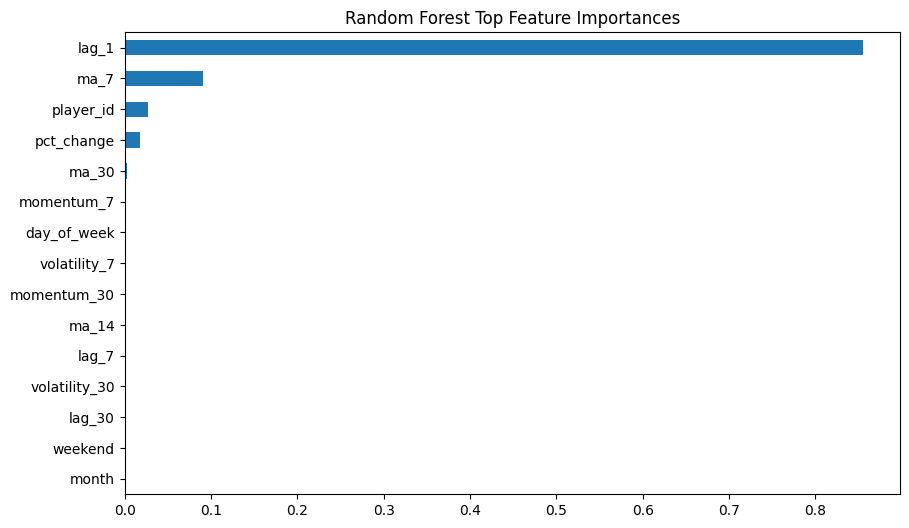

In [67]:
#Lets see what are the most important features
import matplotlib.pyplot as plt
import seaborn as sns

important_ft = pd.Series(rf.feature_importances_, index= X_train.columns)

important_ft.sort_values().plot(kind= "barh", figsize= (10,6))

plt.title("Random Forest Top Feature Importances")
plt.show()

The Random Forest model performed significantly better than both baseline models. Suprisingly, it only considered 4 features as important:
- Lag_1: The price of the day before
- ma_7: The average price of the past seven days
- The player ID, which is actually good as it shows that the model captured player specific behaviour
- pct_change: the percentage change between a day and the day before

For the model, lag_1 is the most dominant feature, which makes sense as in most time-series, yesterday's price is one of the strngest predictor today's price. However, the other feature are also important, therefore we might have to use another model that can use the other features as well.

In [64]:
#XGBoost model
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimator= 300, learning_rate= 0.1, max_depth= 8, subsample= 0.8, colsample_bytree= 0.8, random_state= 42)

xgb.fit(X_train, y_train)

xgb_prediction = xgb.predict(X_test)

In [65]:
mae_xgb = mean_absolute_error(y_test, xgb_prediction)
mape_xgb = mean_absolute_percentage_error(y_test, xgb_prediction)
print(f"On average, the model's predictions are off by {mae_xgb:.2f} coins, with percentage errors averaging {mape_xgb*100:.2f}% across all players in the dataset.")

On average, the model's predictions are off by 447.80 coins, with percentage errors averaging 4.84% across all players in the dataset.


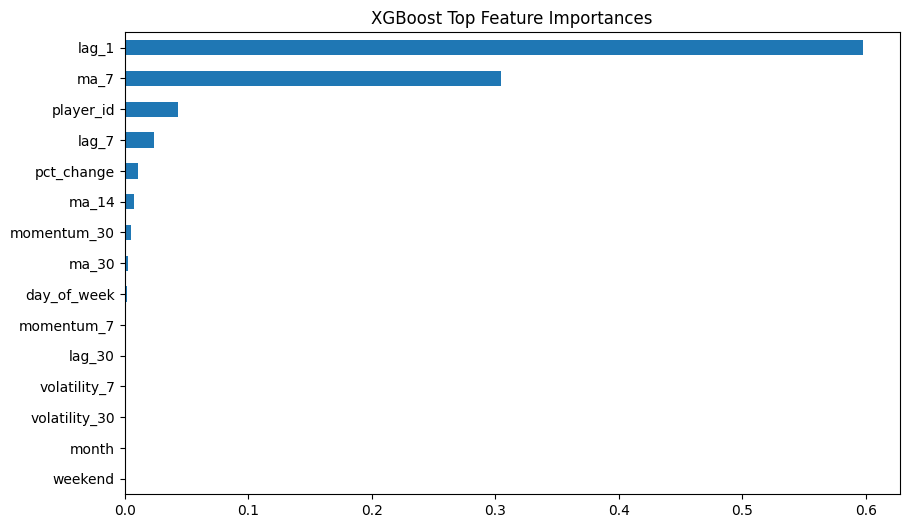

In [68]:
important_ft = pd.Series(xgb.feature_importances_, index= X_train.columns)

important_ft.sort_values().plot(kind= "barh", figsize= (10,6))

plt.title("XGBoost Top Feature Importances")
plt.show()

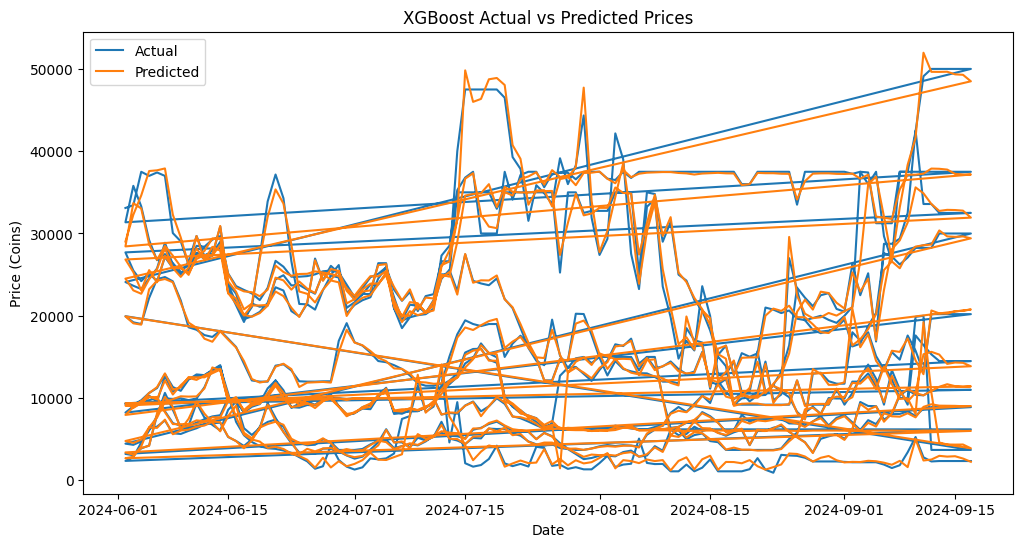

In [75]:
#Predictions vs Actual plot
plt.figure(figsize= (12,6))
plt.plot(test["date"], y_test, label= "Actual")
plt.plot(test["date"], xgb_prediction, label= "Predicted")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price (Coins)")
plt.title("XGBoost Actual vs Predicted Prices")
plt.show()